# 加州禁烟：SCM/RCM/SDID

> 本附录是第五章《如果没有政策，会发生什么》的配套实操材料。第五章正文讲思路与适用条件，本附录讲怎么落地：用同一份加州禁烟数据，依次跑通合成控制法（SCM）、Lasso 型合成控制、回归控制法（RCM/GSC）与合成 DID（SDID），并解读关键输出。
>
> **运行环境**：本文件是 Jupyter Notebook 格式（`.ipynb`），可在 VS Code 中借助 [nbstata](https://nbstata.readthedocs.io/) 内核执行 (配置方法参见 [数据分析与经济决策](https://lianxhcn.github.io/ds2026/) 第 2-4 章)，或通过 [Stata-MCP](https://aidea-labs.com/mcp-for-stata) 调用本地 Stata 运行。习惯直接在 Stata 中操作的读者，可使用配套的简化版 [A05_counterfactual_replication.do](../lecture/appendix/A05_counterfactual_replication.do)（纯代码、无讲解）。
>
> **数据**：香烟消费面板 `smoking.dta` / `prop99_example.dta`，39 个州、1970–2000 年，加州（state==3）于 1989 年实施 Proposition 99。前者用于 SCM/Lasso/RCM 部分，后者（Clarke 等提供）用于 SDID 部分，两者是同一案例的不同整理版本。
>
> **需要的外部命令**：`synth2`、`rcm`、`sdid`、`schemepack`（绘图模板）。首次运行请先安装（见下一单元）。


## 环境准备

首次运行时安装外部命令与绘图模板；已安装可跳过。`nbstata` 环境下每个代码单元相当于一段 do 文件。

In [20]:
* 安装外部命令（首次运行时取消注释执行）
* ssc install synth2, replace
* ssc install rcm, replace
* ssc install sdid, replace all
* ssc install schemepack, replace   // 提供 white_tableau 等绘图模板

set scheme white_tableau            // 全局绘图风格

In [21]:
%set graph_width = 6.5in 

graph size was (8.0in, 6.0in), is now (6.5in, 6.0in).


In [22]:
%set graph_height = 4.5in 

graph size was (6.5in, 6.0in), is now (6.5in, 4.5in).


## 数据与 donor pool

先载入数据、设定面板结构，并画出第五章开篇那张「加州 vs 其余 38 州」的原始数据图。加州是 `state==3`，是唯一的处理单位；其余 38 个州构成 donor pool（候选对照池）。

这张图对应正文 **图 5.1**。它要传达的唯一信息：加州政策后（1989 年竖线右侧）的走势看得见，但「没有政策的加州」这条线不在图上——本附录接下来所有方法，都是在补出这条看不见的线。

In [23]:
* 数据来源（j-hai/synth-stata 镜像），课程包内也附有本地副本
global net "https://github.com/j-hai/synth-stata/raw/refs/heads/main/s"
use "$net/smoking.dta", clear

xtset state year
des                 // 数据概况：state, year, cigsale 及若干预测变量
sum, sep(0)

(Tobacco Sales in 39 US States)

Panel variable: state (strongly balanced)
 Time variable: year, 1970 to 2000
         Delta: 1 unit

Contains data from https://github.com/j-hai/synth-stata/raw/refs/heads/main/s/s
> moking.dta
 Observations:         1,209                  Tobacco Sales in 39 US States
    Variables:             7                  11 Nov 2007 23:38
-------------------------------------------------------------------------------
Variable      Storage   Display    Value
    name         type    format    label      Variable label
-------------------------------------------------------------------------------
state           long    %14.0g     state      state no
year            float   %9.0g                 year
cigsale         float   %9.0g                 cigarette sale per capita (in
                                                packs)
lnincome        float   %9.0g                 log state per capita gdp
beer            float   %9.0g                 beer consumption 

**图 5.1 的绘制**：把数据 reshape 成宽格式，加州（`cig3`）画成黑色粗线，其余 38 州画成浅色细线叠加。

(Tobacco Sales in 39 US States)
(j = 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
>  29 30 31 32 33 34 35 36 37 38 39)

Data                               Long   ->   Wide
-----------------------------------------------------------------------------
Number of observations            1,209   ->   31          
Number of variables                   7   ->   196         
j variable (39 values)            state   ->   (dropped)
xij variables:
                                    cig   ->   cig1 cig2 ... cig39
                                    age   ->   age1 age2 ... age39
                                    lny   ->   lny1 lny2 ... lny39
                                      p   ->   p1 p2 ... p39
                                   beer   ->   beer1 beer2 ... beer39
-----------------------------------------------------------------------------


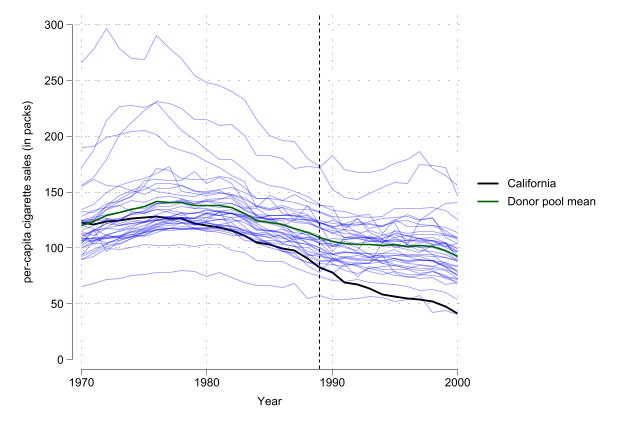

In [24]:
use "$net/smoking.dta", clear
rename (cigsale age15to24 lnincome retprice) (cig age lny p)

reshape wide cig age lny p beer, j(state) i(year)
order year cig* age* lny* p* beer*
keep year cig*

* 生成 38 个 donor pool 州的香烟销售均值
* 注意：cig3 是加州 CA，需要排除
local donor_vars
foreach i of numlist 1 2 4(1)39 {
    local donor_vars `donor_vars' cig`i'
}

egen cig_donor_mean = rowmean(`donor_vars')
label var cig_donor_mean "Donor pool mean"

#delimit ;
twoway
    (tsline cig3, lcolor(black) lw(medthick))         // 加州 CA
    ,
    ytitle("per-capita cigarette sales (in packs)")
    xtitle("Year")
    tline(1989, lpattern(shortdash) lcolor(black))
    tlabel(1970(5)2000) ylabel(0(50)300);
#delimit cr

* 叠加其余 38 州（donor pool）
foreach i of numlist 1 2 4(1)39 {
    addplot: tsline cig`i', ///
        lcolor(blue%40) lw(thin) ///
        ylabel(0(50)300) 
}

* 叠加 38 个 donor pool 州的平均值
* 深绿色；线宽为默认值的 1.3 倍
addplot: tsline cig_donor_mean, ///
    lcolor("green*1.3") lw(*1.3) ///
    ylabel(0(50)300) ///
    legend(order(1 "California" 40 "Donor pool mean") ///
           ring(0) pos(2) cols(1))

## 合成控制法（SCM）

合成控制法用 donor pool 中若干州的加权组合，拼出「合成加州」。`synth2` 是对经典 `synth` 的增强版，语法直观、自带出图。

命令逐项解读：

- `synth2 cigsale <预测变量列表>`：被解释变量是 `cigsale`，后面是用于匹配的预测变量；
- `cigsale(1988) cigsale(1980) cigsale(1975)`：把特定年份的结果变量也作为匹配目标（政策前多个时点对齐）；
- `trunit(3)`：处理单位是第 3 个州（加州）；
- `trperiod(1989)`：处理开始于 1989 年；
- `xperiod(1980(1)1988)`：预测变量的匹配窗口；
- `fig nested allopt`：出图、使用 nested 优化、尝试全部优化器（更稳但更慢）。

(Tobacco Sales in 39 US States)

Panel variable: state (strongly balanced)
 Time variable: year, 1970 to 2000
         Delta: 1 unit
Fitting results in the pretreatment periods:
-------------------------------------------------------------------------------
> -
 Treated Unit             : California     Treatment Time           :       198
> 9
-------------------------------------------------------------------------------
> -
 Number of Control Units  =         38     Root Mean Squared Error  =    1.7556
> 7
 Number of Covariates     =          7     R-squared                =    0.9743
> 4
-------------------------------------------------------------------------------
> -

Covariate balance in the pretreatment periods:
-------------------------------------------------------------------------------
> -----
     Covariate     |  V.weight    Treated    Synthetic Control     Average Cont
> rol  
                   |                        Value          Bias   Value        
> Bias 
------

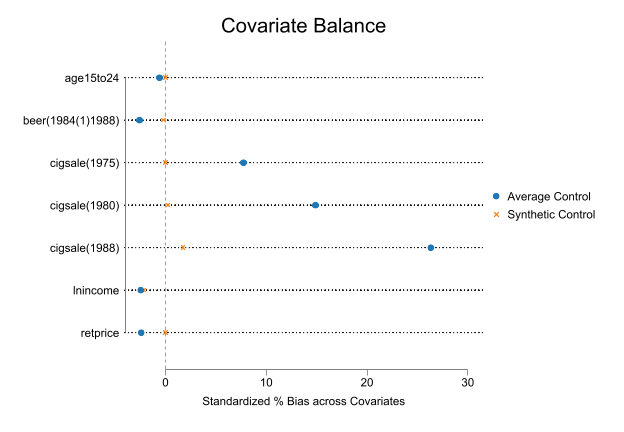

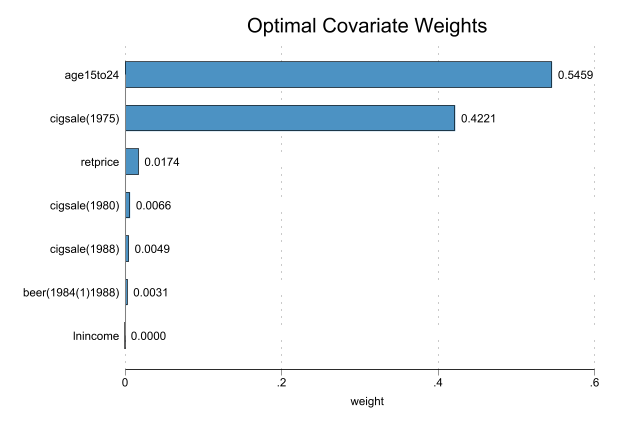

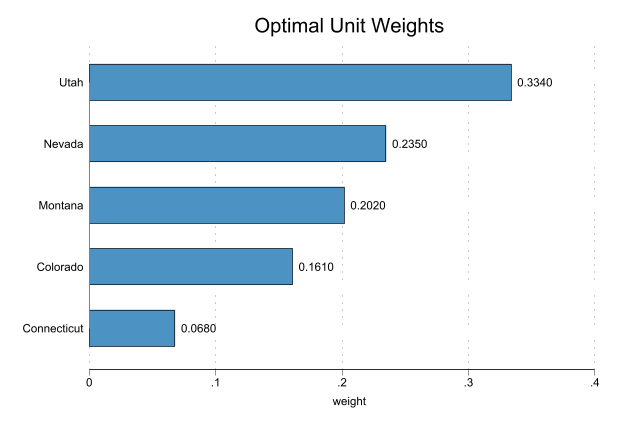

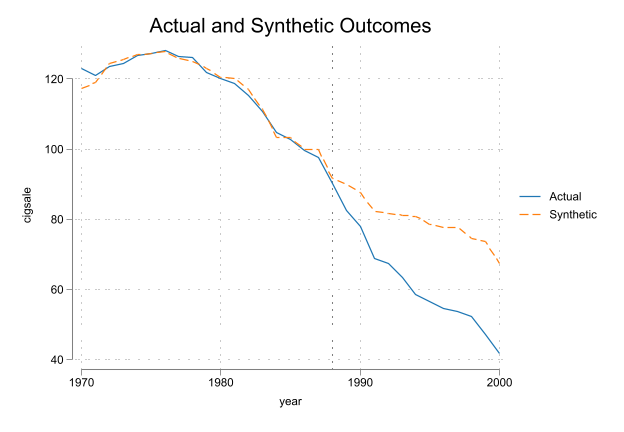

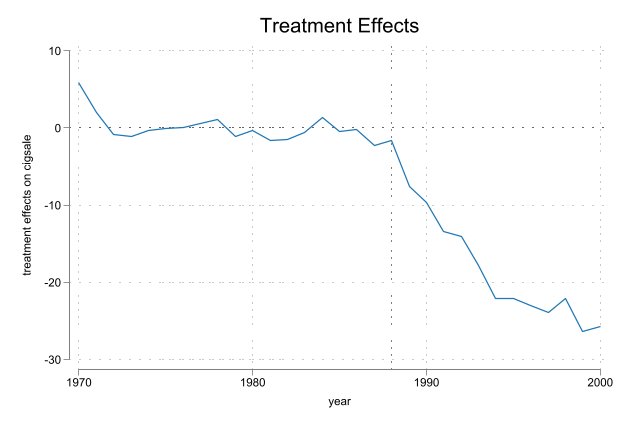

In [25]:
use "$net/smoking.dta", clear
xtset state year

synth2 cigsale lnincome age15to24 retprice beer(1984(1)1988) ///
       cigsale(1988) cigsale(1980) cigsale(1975),            ///
       trunit(3) trperiod(1989) xperiod(1980(1)1988)         ///
       fig nested allopt frame(CAdata)

**输出解读 1：单位权重（Optimal Unit Weights）**

`synth2` 在 38 个州里只给 5 个州分配了非零权重，其余 33 个州权重为零：

| 州 | 权重 |
|---|---|
| Utah 犹他 | 0.334 |
| Nevada 内华达 | 0.235 |
| Montana 蒙大拿 | 0.202 |
| Colorado 科罗拉多 | 0.161 |
| Connecticut 康涅狄格 | 0.068 |

这 5 个权重非负、且加总为 1（0.334+0.235+0.202+0.161+0.068 = 1.000），正是第五章强调的**凸组合约束**。所谓「合成加州」，就是这 5 条州曲线按此权重的加权平均——一个具体的「配方」。

**输出解读 2：预测变量平衡表**

`synth2` 还会报告 R-squared（本例约 0.974）与一张平衡表，对比「真实加州」「合成加州」「所有对照州简单平均」在各预测变量上的取值。合成加州应当在多数预测变量上比简单平均更贴近真实加州——这是 SCM 相对 DID 的改进所在。

**导出三张图**：`synth2` 把结果存在若干命名图形里，逐一显示并导出。

file scm-rcm-Abadie10-Tab01-Fig.png written in PNG format
file scm-Abadie2010-Fig02-pred.png written in PNG format
file scm-Abadie2010-Fig03-TE.png written in PNG format


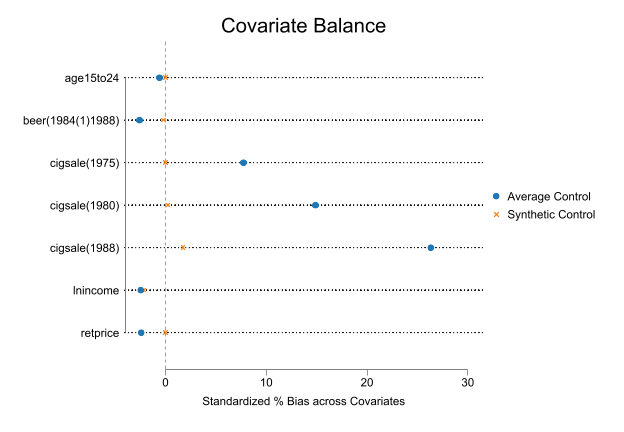

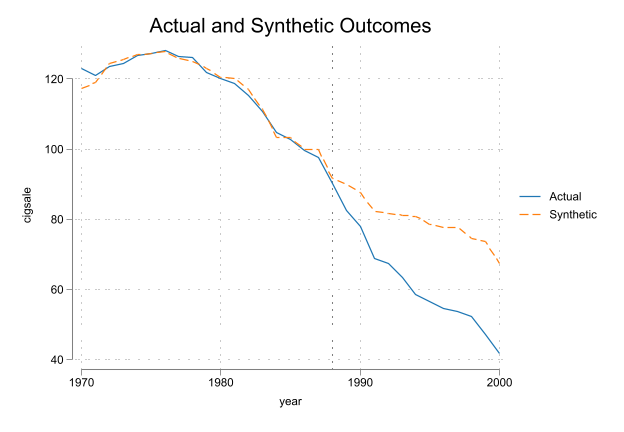

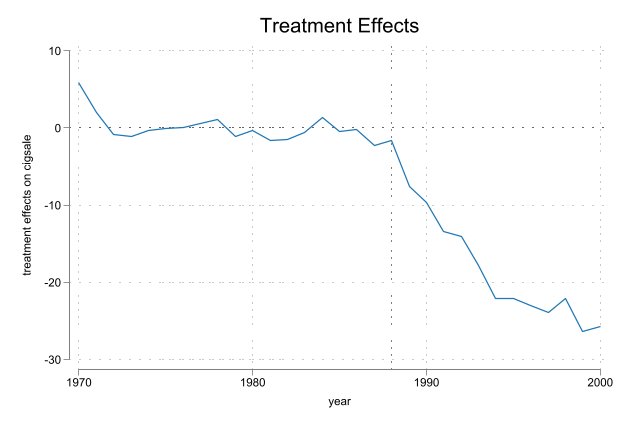

In [26]:
* Table 1 的可视化（真实/合成/简单平均 三者对比）
graph display bias
graph export "scm-rcm-Abadie10-Tab01-Fig.png", replace width(900)

* Figure 2：真实加州 vs 合成加州（政策前拟合 + 政策后缺口）
graph display pred
graph export "scm-Abadie2010-Fig02-pred.png", replace width(900)

* Figure 3：处理效应 = 真实 − 合成（政策后的差距）
graph display eff
graph export "scm-Abadie2010-Fig03-TE.png", replace width(900)

**核心图：5 个非零权重州（正文图 5.2）**

这张图把 5 个非零权重州高亮出来，其余州压成灰色背景。它是理解 SCM 最直观的一张图——抽象的「凸组合权重」在这里变成「三分之一个犹他 + 四分之一个内华达 + ……」。图例里直接标出每个州的权重。

(Tobacco Sales in 39 US States)
file scm-Figure0-non-zero-weights.png written in PNG format


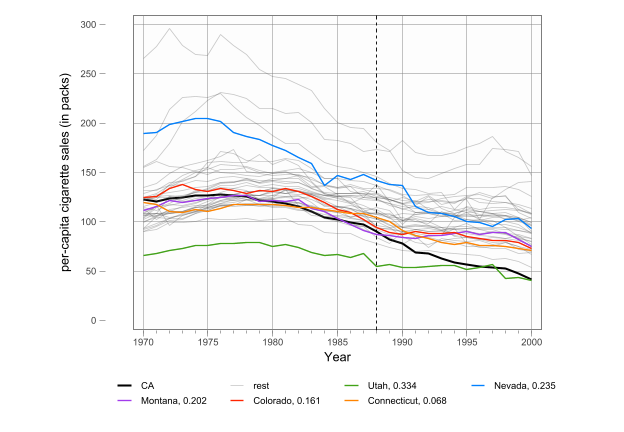

In [27]:
use "$net/smoking.dta", clear
qui rename (cigsale) (cig)
qui keep state year cig
qui reshape wide cig, j(state) i(year)
qui order year cig*
qui keep year cig*

set scheme rainbow
#delimit ;
twoway
    (tsline cig3, lcolor(black) lw(*1.5))             // 加州 CA
    ,
    ytitle("per-capita cigarette sales (in packs)")
    xtitle("Year")
    tline(1988, lp(shortdash) lc(black))
    tlabel(1970(5)2000) tmtick(##5)
    ylabel(0(50)300)
    aspect(0.8) ysize(4) xsize(5.5)
    legend(order(1 "CA"));
#delimit cr

* 其余州压成灰色背景
foreach i of numlist 1 2 4(1)39 {
    addplot: tsline cig`i', lcolor(black*0.7%30) lw(*0.6) lp(solid) ///
        ylabel(0(50)300) tlabel(1970(5)2000) tmtick(##5)           ///
        legend(order(1 "CA" 2 "rest"))
}
* 高亮 5 个非零权重州
foreach i of numlist 34 21 19 4 5 {
    addplot: tsline cig`i', lw(*1) lp(solid)                       ///
        ylabel(0(50)300) tlabel(1970(5)2000) tmtick(##5)          ///
        legend(order(1 "CA" 2 "rest"                              ///
                     40 "Utah, 0.334" 41 "Nevada, 0.235"          ///
                     42 "Montana, 0.202" 43 "Colorado, 0.161"     ///
                     44 "Connecticut, 0.068") row(2))
}
graph export "scm-Figure0-non-zero-weights.png", replace width(900)
set scheme white_tableau

**SCM 小结与局限**

- 反事实来源：donor pool 的凸组合；
- 识别压力：donor pool 纯净性（对照州不能受类似控烟政策污染）、预测变量选择、政策前拟合质量；
- 推断：因只有一个处理单位，依赖安慰剂/置换检验（把每个对照州轮流当假处理组，看真实加州的政策后缺口是否显著异常）；
- 约束的代价：凸组合防止了危险外推，但若真实反事实不在 donor pool 凸包内，政策前会拟合不好。

## Lasso 型合成控制：放开约束会怎样

第五章讲到 SCM 与 RCM 的差别是「约束 vs 灵活」。这一节用 Lasso 直接演示：把 SCM 的「非负、加总为一」约束换成 Lasso 惩罚，选出的对照州会不同，还会出现负系数和截距。

先把数据转成宽格式（每个州的 `cigsale` 成为一列），加州记为 `cig0`。

In [28]:
use "$net/smoking.dta", clear
replace state = 0 if state == 3          // 把加州改记为 0，便于作被解释变量
rename (cigsale age15to24 lnincome retprice) (cig age lny p)
reshape wide cig age lny p beer, j(state) i(year)
order year cig* age* lny* p* beer*
save "smoking_wide.dta", replace

(Tobacco Sales in 39 US States)
(31 real changes made)
(j = 0 1 2 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
>  29 30 31 32 33 34 35 36 37 38 39)

Data                               Long   ->   Wide
-----------------------------------------------------------------------------
Number of observations            1,209   ->   31          
Number of variables                   7   ->   196         
j variable (39 values)            state   ->   (dropped)
xij variables:
                                    cig   ->   cig0 cig1 ... cig39
                                    age   ->   age0 age1 ... age39
                                    lny   ->   lny0 lny1 ... lny39
                                      p   ->   p0 p1 ... p39
                                   beer   ->   beer0 beer1 ... beer39
-----------------------------------------------------------------------------
(file smoking_wide.dta not found)
file smoking_wide.dta saved


**Lasso 选州（plugin 选 λ）**

用政策前样本（`year <= 1989`）把加州 `cig0` 对其余各州回归，Lasso 自动做变量选择。`select(plugin)` 用理论公式确定惩罚参数 λ。

In [29]:
use "smoking_wide.dta", clear
global TreatYear = 1989

lasso linear cig0 cig1-cig39 lny1-lny39 if year <= $TreatYear, select(plugin)
lassocoef                                // 查看被选中的州

(Tobacco Sales in 39 US States)

Computing plugin lambda ...
Iteration 1:     lambda = .9364963   no. of nonzero coef. =  6
Iteration 2:     lambda = .9364963   no. of nonzero coef. =  8
Iteration 3:     lambda = .9364963   no. of nonzero coef. =  7
Iteration 4:     lambda = .9364963   no. of nonzero coef. =  6
Iteration 5:     lambda = .9364963   no. of nonzero coef. =  6

Lasso linear model                          No. of obs        =         18
                                            No. of covariates =         76
Selection: Plugin heteroskedastic

--------------------------------------------------------------------------
         |                                No. of
         |                               nonzero    In-sample
      ID |     Description      lambda     coef.    R-squared          BIC
---------+----------------------------------------------------------------
     * 1 | selected lambda    .9364963         6       0.9961     65.73252
---------------------------

**输出对比：Lasso vs synth2 选出的州**

- Lasso（plugin）选中：cig8, cig15, cig19, cig21, cig29, cig34 + 截距
- synth2 选中：cig4, cig5, cig19, cig21, cig34

两者**部分重叠**（都选了 19=Montana、21=Nevada、34=Utah），但不完全相同。关键区别：Lasso 放开了非负与加总为一的约束，可以选出负系数、并带一个非零截距。同一份数据、同一个处理组，约束松一档，反事实的「配方」就换了一副面孔——这正是第五章「约束 vs 灵活」权衡的活教材。

**Lasso 反事实与 gap 图**

用惩罚系数（`cig0_lasso`）与后选择无惩罚系数（`cig0_post`，即 post-Lasso OLS）两种方式预测加州反事实，画出真实加州、两条合成线及其 gap。

(options xb penalized assumed; linear prediction with penalized coefficients)
(option xb assumed; linear prediction with postselection coefficients)


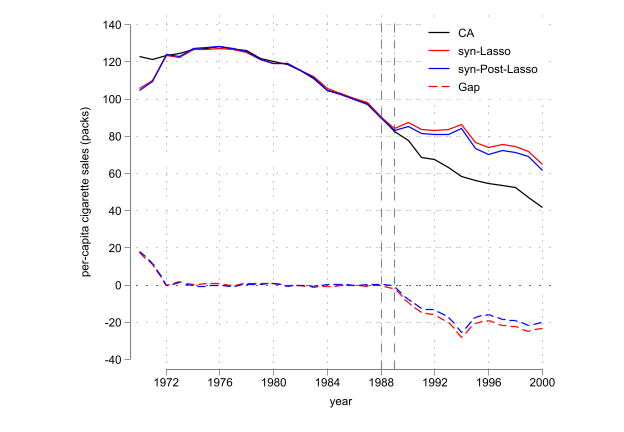

In [30]:
cap dropvars cig0_lasso cig0_post gap*
predict cig0_lasso                       // 惩罚系数预测
predict cig0_post, postselection         // 后选择（无惩罚）系数预测
gen gap_lasso = cig0 - cig0_lasso
gen gap_post  = cig0 - cig0_post

#delimit ;
tw (line cig0       year, lc(black))
   (line cig0_lasso year, lc(red))
   (line cig0_post  year, lc(blue))
   (line gap_lasso  year, lc(red)  lp(dash))
   (line gap_post   year, lc(blue) lp(dash))
   ,
   ylabel(-40(20)140) xlabel(1972(4)2000)
   xline($TreatYear 1988, lc(gray) lp(dash_dot))
   yline(0, lc(black) lp(dot))
   xtitle("year") ytitle("per-capita cigarette sales (packs)")
   legend(order(1 "CA" 2 "syn-Lasso" 3 "syn-Post-Lasso" 4 "Gap")
          ring(0) col(1) pos(2))
   aspect(0.8);
#delimit cr

**进阶：λ 的选择与时间安慰剂检验（可选）**

除 `plugin` 外，还可用交叉验证（`cv`）或自适应交叉验证（`adaptive`）选 λ。把「处理年份」提前到真实政策之前（如 1984）做**时间安慰剂检验**：如果在假想的政策年也测出明显 gap，说明方法在制造假阳性。下面三段分别用 plugin / CV / adaptive 演示，均把 `TreatYear` 设为 1984。

In [32]:
cap program drop lasso_smoking_graph
program define lasso_smoking_graph

#d ;
tw (line cig0       year, lc(black)) 
   (line cig0_lasso year, lc(red))   
   (line cig0_post  year, lc(blue))
   (line gap_lasso  year, lc(red)  lp(dash))
   (line gap_post   year, lc(blue) lp(dash))
   , 
   ylabel(-40(20)140)   xlabel(1972(4)2000)
   xline($TreatYear 1988, lc(gray) lp(dash_dot)) 
   yline(0, lc(black) lp(dot)) 
   xtitle("year") ytitle("per-capita cigarette sales (packs)")
   legend(order(1 "CA" 2 "syn-Lasso" 3 "syn-Post-Lasso" 4 "Gap") ring(0) col(1) pos(2)) 
   aspect(0.8) ;    //scheme(s1mono) 
#d cr 

end

(Tobacco Sales in 39 US States)

Computing plugin lambda ...
Iteration 1:     lambda = 1.101972   no. of nonzero coef. =  4
Iteration 2:     lambda = 1.101972   no. of nonzero coef. =  4

Lasso linear model                          No. of obs        =         13
                                            No. of covariates =         76
Selection: Plugin heteroskedastic

--------------------------------------------------------------------------
         |                                No. of
         |                               nonzero    In-sample
      ID |     Description      lambda     coef.    R-squared          BIC
---------+----------------------------------------------------------------
     * 1 | selected lambda    1.101972         4       0.9226     66.18965
--------------------------------------------------------------------------
* lambda selected by plugin formula assuming heteroskedastic errors.
(options xb penalized assumed; linear prediction with penalized coeffici

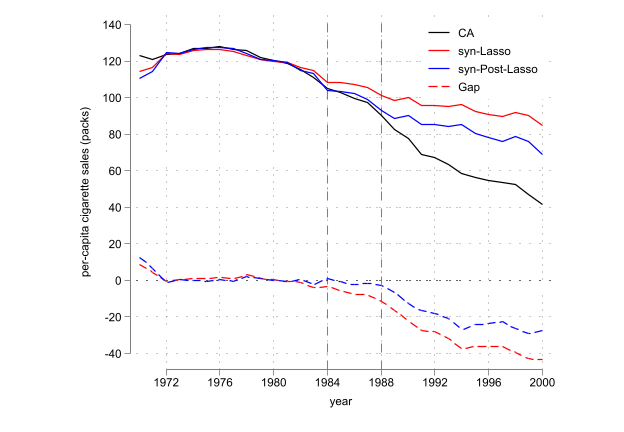

In [33]:
* A. plugin，安慰剂年 1984
use "smoking_wide.dta", clear
global TreatYear = 1984
lasso linear cig0 cig1-cig39 lny1-lny39 if year <= $TreatYear, select(plugin)
cap dropvars cig0_lasso cig0_post gap*
predict cig0_lasso
predict cig0_post, postselect
gen gap_lasso = cig0 - cig0_lasso
gen gap_post  = cig0 - cig0_post
lasso_smoking_graph         // 绘图, 自编程序

(Tobacco Sales in 39 US States)

Lasso linear model                          No. of obs        =         13
                                            No. of covariates =         76
Selection: Cross-validation                 No. of CV folds   =         10

--------------------------------------------------------------------------
         |                                No. of      Out-of-      CV mean
         |                               nonzero       sample   prediction
      ID |     Description      lambda     coef.    R-squared        error
---------+----------------------------------------------------------------
       1 |    first lambda    6.481684         0      -0.1541     52.97234
      84 |   lambda before    .1364332         7       0.9865     .6183389
    * 85 | selected lambda    .1302321         7       0.9866     .6170244
      86 |    lambda after    .1243129         7       0.9865     .6179679
      88 |     last lambda    .1132693         8       0.9863     

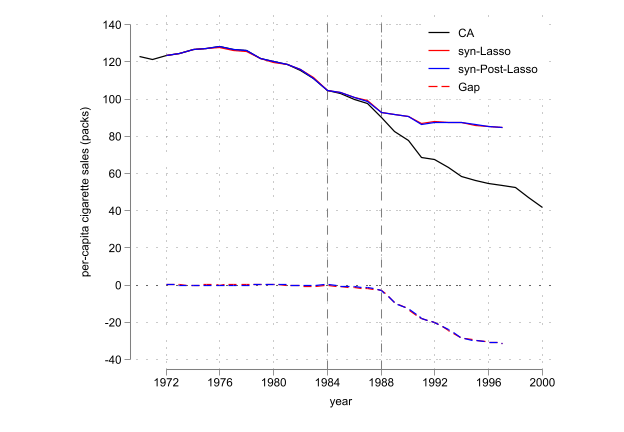

In [35]:
* B. 10 折交叉验证选 λ，安慰剂年 1984
use "smoking_wide.dta", clear
global TreatYear = 1984
lasso linear cig0 cig1-cig39 lny1-lny39 ///
      if year <= $TreatYear, ///
      select(cv, fold(10)) ///
      nolog
cap dropvars cig0_lasso cig0_post gap*
predict cig0_lasso
predict cig0_post, postselect
gen gap_lasso = cig0 - cig0_lasso
gen gap_post  = cig0 - cig0_post
lasso_smoking_graph         // 绘图, 自编程序
* 注：若 TreatYear<=1983 则政策前样本太少，10 折 CV 无法执行

(Tobacco Sales in 39 US States)

Lasso linear model                         No. of obs         =         13
                                           No. of covariates  =         76
Selection: Adaptive                        No. of lasso steps =          2

Final adaptive step results
--------------------------------------------------------------------------
         |                                No. of      Out-of-      CV mean
         |                               nonzero       sample   prediction
      ID |     Description      lambda     coef.    R-squared        error
---------+----------------------------------------------------------------
      98 |    first lambda    1493.126         0      -0.1400     52.32459
     166 |   lambda before    2.670679         6       0.9883     .5367961
   * 167 | selected lambda    2.433423         6       0.9883     .5357959
     168 |    lambda after    2.217244         6       0.9883     .5373354
     184 |     last lambda    .5004364

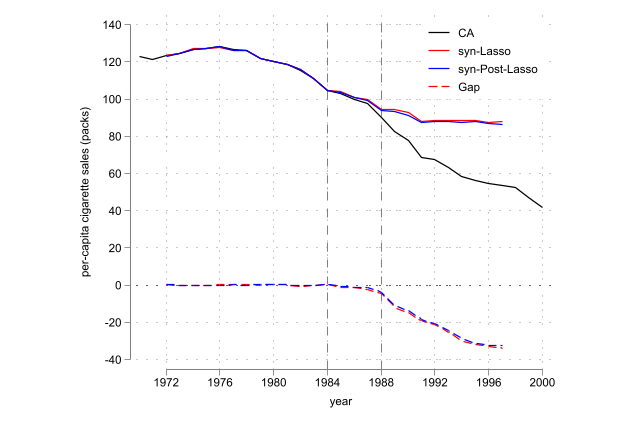

In [36]:
* C. 自适应 CV 选 λ，安慰剂年 1984
use "smoking_wide.dta", clear
global TreatYear = 1984
lasso linear cig0 cig1-cig39 lny1-lny39 ///
      if year <= $TreatYear, ///
      select(adaptive, fold(10)) ///
      nolog
cap dropvars cig0_lasso cig0_post gap*
predict cig0_lasso
predict cig0_post, postselect
gen gap_lasso = cig0 - cig0_lasso
gen gap_post  = cig0 - cig0_post
lasso_smoking_graph         // 绘图, 自编程序

**小结：**

1. CV 与 adaptive-CV 更偏向「预测」，但样本不能太小（政策前时期太少会失败）；
2. 本例中若用 CV，Lasso 与 post-Lasso 的差异很小；
3. 改变 `fold()` 的数值可观察结果变化；当 K=N 时，K 折 CV 退化为 Jackknife。

Lasso 是通向 RCM 的桥：它演示了「放开凸组合约束 + 正则化选参」的思路，而 RCM 把这套思路系统化为一个可直接调用的命令。

## 回归控制法（RCM / GSC）

`rcm` 命令把上一节的思路封装起来：用未处理样本学习结构、预测处理组的无政策路径，可选 Lasso 做单位选择。语法极简：

(Tobacco Sales in 39 US States)

Panel variable: state (strongly balanced)
 Time variable: year, 1970 to 2000
         Delta: 1 unit

Step 1: Select the suboptimal models
(method lasso specified)

Selecting the suboptimal model...

Step 2: Select the optimal model from the suboptimal models
(criterion cv specified for leave-one-out cross-validation)

Comparing the suboptimal models containing different set of predictors:
--------------------------------------------------------------------
  K |    lambda      CVMSE     R-squared |         Operation        
----+------------------------------------+--------------------------
  1 |    10.3926    138.5578      0.0814 | add cigsale·NewHampshire 
  2 |     8.2359    100.4864      0.3957 | add cigsale·Montana 
  3 |     6.5268     69.0261      0.6068 | add cigsale·Nevada 
  4 |     3.4031     23.8443      0.8784 | add cigsale·Colorado 
  5 |     2.5743     16.4272      0.9222 | add cigsale·Illinois 
  6 |     1.6167      9.7903      0.9623 |

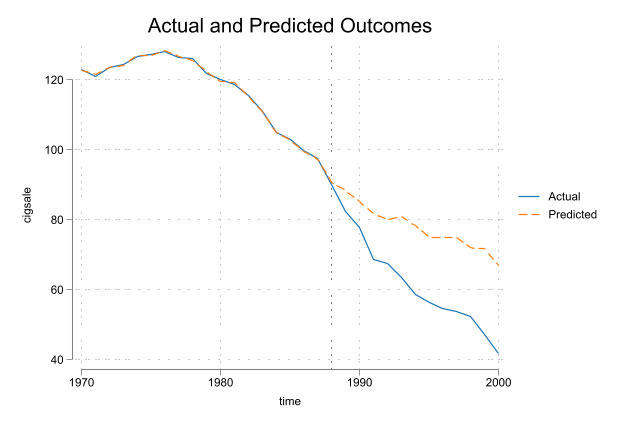

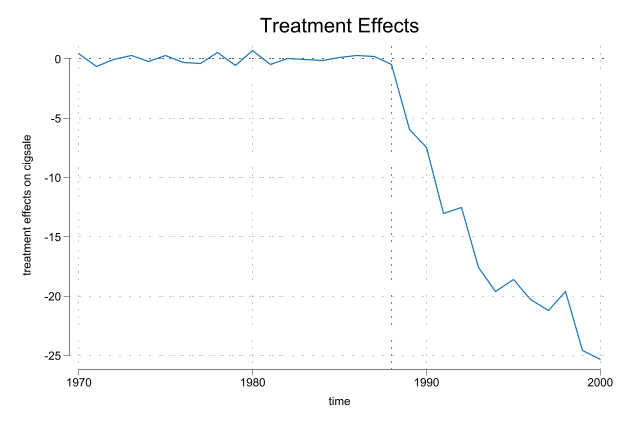

In [38]:
frame reset
use "$net/smoking.dta", clear
xtset state year

rcm cig, trunit(3) trperiod(1989) method(lasso) criterion(cv) frame(te)

* 导出两张图
graph display pred                       // 真实 vs 预测（反事实）
graph export "rcm-Abadie2010-Fig02.png", replace width(900)
graph display eff                        // 处理效应
graph export "rcm-Abadie2010-Fig03.png", replace width(900)

**输出解读：post-lasso OLS 的系数**

`rcm` 报告政策前用 post-lasso OLS 拟合的系数（本例 R² ≈ 0.98）：

| 预测州 | 系数 |
|---|---|
| Colorado | 0.063 |
| Montana | 0.418 |
| Nevada | 0.218 |
| New Hampshire | 0.038 |
| 截距 `_cons` | 12.46 |

对照 F.3 的 SCM 权重（都非负、加总为 1），这里的系数**没有非负约束、不加总为 1、还带一个 12.46 的截距**。这就是「约束 vs 灵活」在数值上的直接体现：RCM 换取了更强的拟合，代价是系数不再有「配方份额」那样干净的解释。

**处理效应**：政策后各年的处理效应从 1989 年的约 −8 逐步扩大到 2000 年的约 −33，政策后期平均约 **−23.1**（packs per capita）。注意这个数字与 SCM、SDID 的口径不同（见 F.7 对比），不能直接比较哪个「更准」。

### 安慰剂检验

包括两类：

- 截面安慰剂检验：把每个对照州轮流当假处理组，计算其 gap，画出真实加州的 gap 是否显著异常；
- 时间安慰剂检验：把处理年份提前到真实政策之前（如 1985），看是否也测出明显 gap。

上述两个检验可以通过 `placebo()` 选项一次性完成。


Step 1: Select the suboptimal models
(method lasso specified)

Selecting the suboptimal model...

Step 2: Select the optimal model from the suboptimal models
(criterion cv specified for leave-one-out cross-validation)

Comparing the suboptimal models containing different set of predictors:
--------------------------------------------------------------------
  K |    lambda      CVMSE     R-squared |         Operation        
----+------------------------------------+--------------------------
  1 |    10.3926    138.5578      0.0814 | add cigsale·NewHampshire 
  2 |     8.2359    100.4864      0.3957 | add cigsale·Montana 
  3 |     6.5268     69.0261      0.6068 | add cigsale·Nevada 
  4 |     3.4031     23.8443      0.8784 | add cigsale·Colorado 
  5 |     2.5743     16.4272      0.9222 | add cigsale·Illinois 
  6 |     1.6167      9.7903      0.9623 | add cigsale·Connecticut 
  7 |     0.8047      5.9113      0.9853 | add cigsale·Nebraska 
  8 |     0.4605      5.0471      0.9906 |

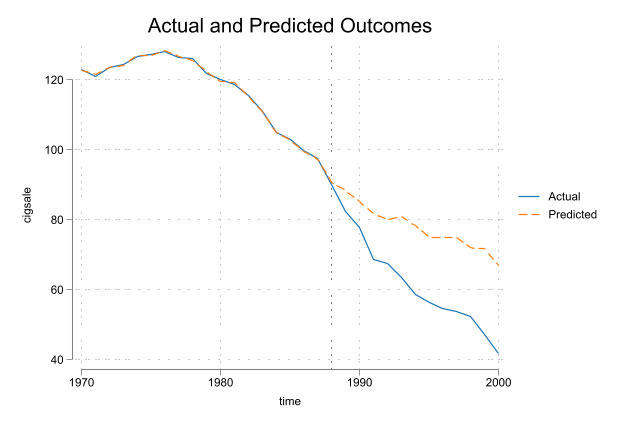

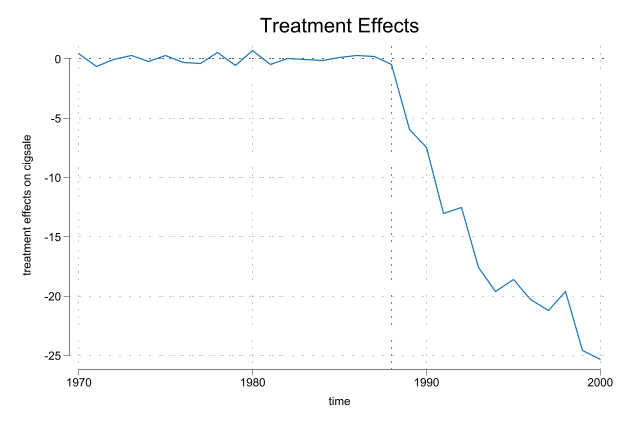

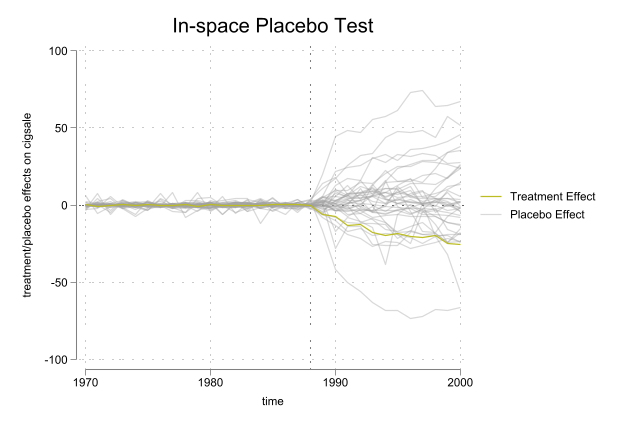

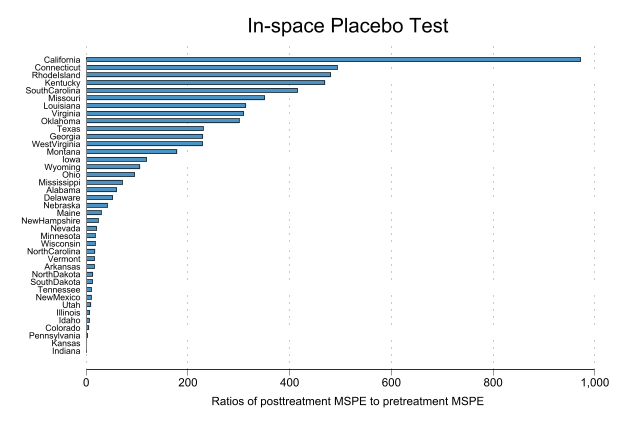

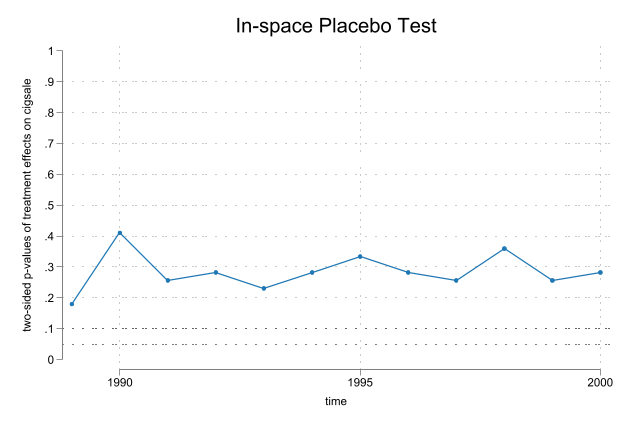

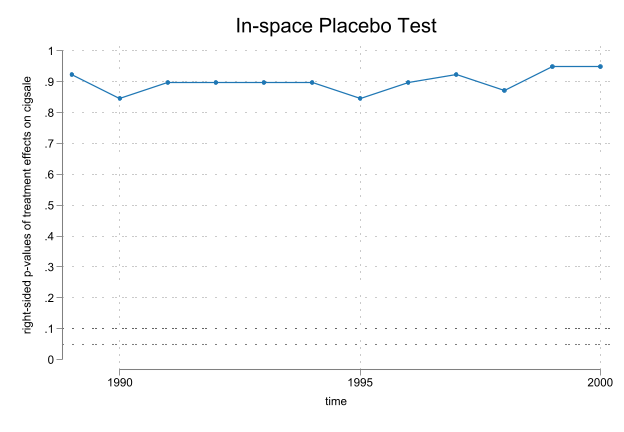

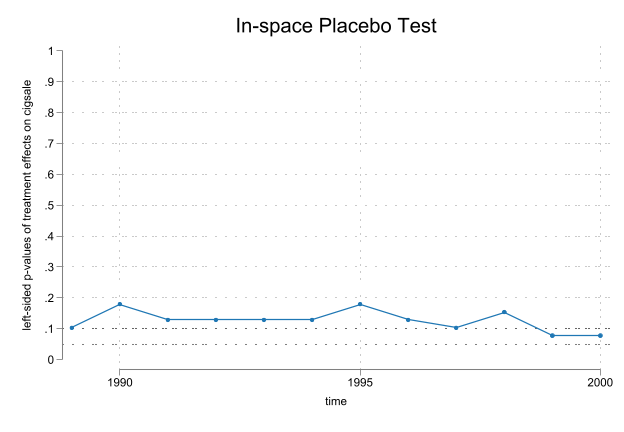

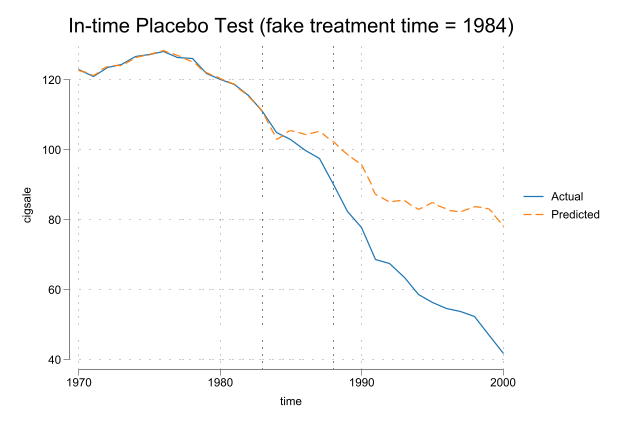

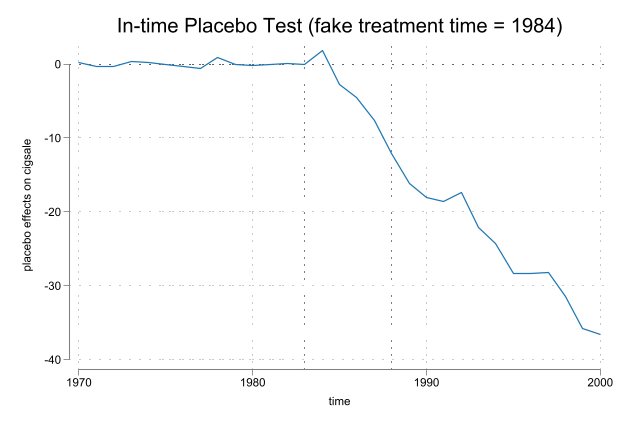

In [40]:
//Implement placebo tests using all fake treatment units in the donor pool, and fake treatment time 1985
rcm cig, trunit(3) trperiod(1989) method(lasso) criterion(cv) ///
         placebo(unit period(1984))

**小结：**

从上述结果来看，RCM 的反事实构造与 SCM 相比，拟合更好、gap 更小，但系数解释不再直观。安慰剂检验显示，真实加州的 gap 在对照组中显著异常，支持政策效应的存在。

然而，时间安慰剂检验显示，若把处理年份提前到 1984 年，仍然测出明显 gap，说明 RCM 在政策前时期的拟合可能存在过度拟合的风险。可以考虑在政策前时期增加更多预测变量，或使用更严格的正则化方法（如 adaptive-CV）来缓解过拟合。

## 合成 DID（SDID）

SDID 同时给单位和时间加权。`sdid` 命令（Clarke 等）语法为 `sdid Y S T D`，其中 D 是二元处理变量。SDID 部分使用 Clarke 提供的 `prop99_example.dta`（与前面同案例、不同整理版本，处理变量已命名为 `treated`）。

In [41]:
webuse set www.damianclarke.net/stata/
webuse prop99_example.dta, clear

encode state, gen(id_state)
xtset id_state year
xtdes                                    // 确认为强平衡面板：39 州 × 31 年

(prefix now "http://www.damianclarke.net/stata")

Panel variable: id_state (strongly balanced)
 Time variable: year, 1970 to 2000
         Delta: 1 unit

id_state:  1, 2, ..., 39                                     n =         39
    year:  1970, 1971, ..., 2000                             T =         31
           Delta(year) = 1 unit
           Span(year)  = 31 periods
           (id_state*year uniquely identifies each observation)

Distribution of T_i:   min      5%     25%       50%       75%     95%     max
                        31      31      31        31        31      31      31

     Freq.  Percent    Cum. |  Pattern
 ---------------------------+---------------------------------
       39    100.00  100.00 |  1111111111111111111111111111111
 ---------------------------+---------------------------------
       39    100.00         |  XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX


**基础用法**：`vce(placebo)` 用安慰剂法做推断（适合单一处理组的情形），`seed()` 固定随机种子以复现。

In [42]:
sdid packspercapita state year treated, vce(placebo) seed(1213)

Placebo replications (50). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
packsperca~a |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
     treated | -15.60383    9.87941    -1.58    0.114   -34.96712     3.75946
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.


**输出解读**：ATT ≈ **−15.60**（packs per capita），安慰剂标准误约 9–10，p 值约 0.08–0.11（因随机抽样，换 seed 或 reps 会略有变化）。这是 SDID 对全体政策后时期加权平均的 ATT。

**带图输出**：`graph` 选项出两张图——趋势图（真实 vs 合成加州）与权重图（单位权重 + 时间权重）。`graph_export(stub, .png)` 会自动生成 `stub_trendsYYYY.png` 和 `stub_weightsYYYY.png`（YYYY 为处理年份 1989）。这是正文 **图 5.4** 的来源。

Placebo replications (100). This may take some time.
----+--- 1 ---+--- 2 ---+--- 3 ---+--- 4 ---+--- 5
..................................................     50
..................................................     100


Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
packsperca~a |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
     treated | -15.60383    9.68177    -1.61    0.107   -34.57975     3.37209
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.
(file SDID_cig_002weights1989.png not found)
file SDID_cig_002weights1989.png written in PNG format
(file SDID_cig_002trends1989.png not found)
file SDID_cig_002trends1989.png written in PNG format


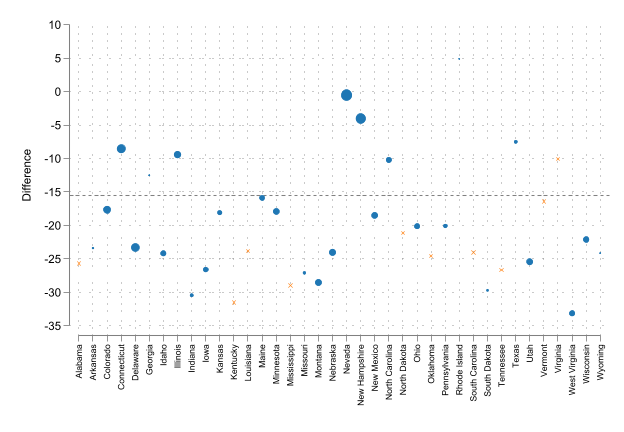

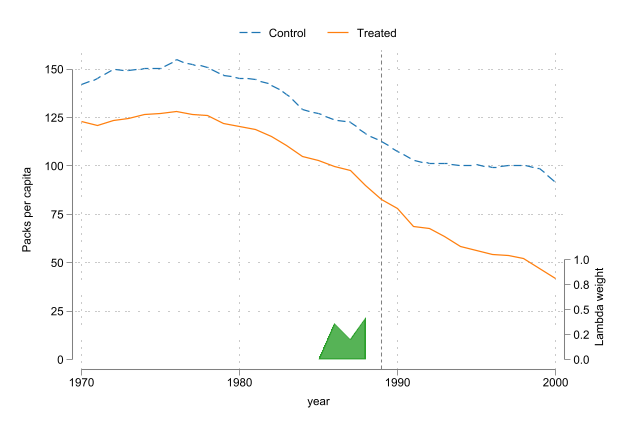

In [43]:
#delimit ;
sdid packspercapita state year treated,
     vce(placebo) seed(1213) reps(100)
     graph g1on
     g2_opt(ylabel(0(25)150) ytitle("Packs per capita") scheme(white_tableau))
     g1_opt(xtitle("") ylabel(-35(5)10) scheme(white_tableau))
     graph_export(SDID_cig_002, .png);
#delimit cr

**三种方法同框对比（正文数值对比的来源）**

`sdid` 的 `method()` 选项可一键切换 SDID / DID / SC，用同一份数据、同一套绘图参数跑三遍，最能看清三者差异。`vce(noinference)` 跳过推断、只出点估计与图，加快速度。



Synthetic Difference-in-Differences Estimator

-----------------------------------------------------------------------------
packsperca~a |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------------------------------------------------------------
     treated | -15.60383          .        .        .           .           .
-----------------------------------------------------------------------------
95% CIs and p-values are based on large-sample approximations.
Refer to Arkhangelsky et al., (2021) for theoretical derivations.
(file comp_cig_01_sdidweights1989.png not found)
file comp_cig_01_sdidweights1989.png written in PNG format
(file comp_cig_01_sdidtrends1989.png not found)
file comp_cig_01_sdidtrends1989.png written in PNG format


Difference-in-Differences Estimator

-----------------------------------------------------------------------------
packsperca~a |     ATT     Std. Err.     t      P>|t|    [95% Conf. Interval]
-------------+---------

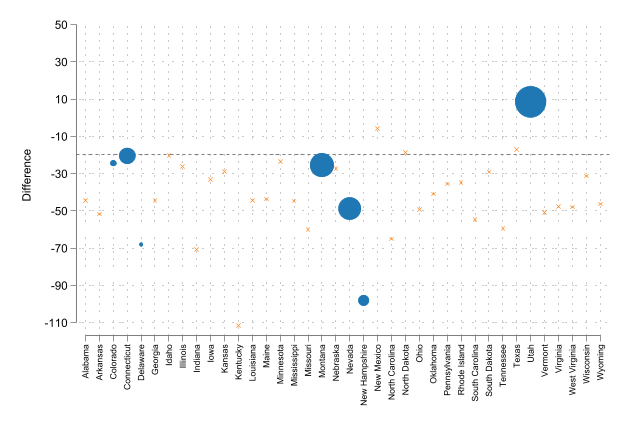

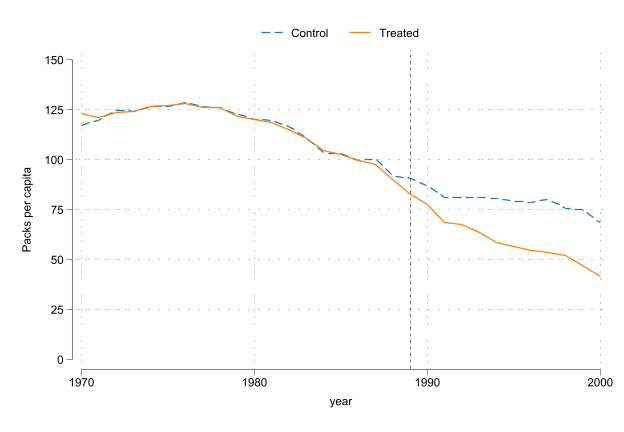

In [44]:
global yx "packspercapita state year treated"
global scheme "scheme(white_tableau)"

* SDID
sdid $yx, method(sdid) vce(noinference) graph                     ///
     g1_opt(ylabel(-110(20)50) xtitle("") $scheme) g1on           ///
     g2_opt(ylabel(0(25)150) ytitle("Packs per capita") $scheme)  ///
     graph_export(comp_cig_01_sdid, .png)

* DID
sdid $yx, method(did) vce(noinference) graph msize(small)         ///
     g1_opt(ylabel(-110(20)50) xtitle("") $scheme) g1on           ///
     g2_opt(ylabel(0(25)150) ytitle("Packs per capita") $scheme)  ///
     graph_export(comp_cig_02_did, .png)

* SC
sdid $yx, method(sc) vce(noinference) graph msize(small)          ///
     g1_opt(ylabel(-110(20)50) xtitle("") $scheme) g1on           ///
     g2_opt(ylabel(0(25)150) ytitle("Packs per capita") $scheme)  ///
     graph_export(comp_cig_03_sc, .png)

## 数值汇总与口径说明

三种方法在加州数据上给出的 ATT（均为 packs per capita）：

| 方法 | 命令 | ATT | 口径 |
|---|---|---|---|
| DID | `sdid, method(did)` | **−27.3** | 双向 FE、等权平均，政策后全期 |
| SC | `sdid, method(sc)` | **−19.6** | 单位加权，政策后全期 |
| SDID | `sdid, method(sdid)` | **−15.6** | 单位+时间加权，政策后全期 |
| RCM | `rcm, method(lasso)` | **−23.1** | post-lasso 预测，政策后期简单平均 |

**为什么数值不同？** 这不是「谁算错了」，而是反事实构造方式不同的直接后果：

- DID 用等权平均，最受「加州与对照州长期趋势不平行」的拖累，绝对值最大；
- SC 用截面加权贴近加州，缓解了不平行；
- SDID 再叠加时间加权，把更多权重放在与政策期更相关的年份，进一步收窄；
- RCM 的 −23.1 与前三者口径不同（政策后期简单平均、且样本/命令实现不同），**不能与 SDID 的 −15.6 直接比大小**。

**教学要点**：第五章正文只作定性结论（不同方法给出不同数值，因反事实构造方式不同）。若在论文里报告，务必标注每个数字的口径（加权方式、时间范围、推断方法），避免读者误以为某个数「最准」。真正稳健的做法是像 Lane (2025) 那样报告多种方法、看结论方向是否一致，而非纠结单一点估计。

## 延伸与本附录的边界

本附录只做「怎么用」。以下内容留给正文、第七章或专门文献：

- **SDID 的推导**（个体权重与时间权重的优化问题、bootstrap/jackknife 方差、DID/SC/SDID 三估计量的统一形式）见第五章 SDID 幻灯片与 Arkhangelsky et al. (2021)、Clarke et al. (2023)；
- **RDD 的实操**（带宽、局部多项式、密度操纵检验、稳健偏差校正）本案例数据不适用，见第七章扩展阅读中的 Calonico–Cattaneo–Titiunik 系列；
- **交错处理下的 DID 方法选择**（Goodman-Bacon 分解、csdid、Sun–Abraham、BJS 等）是第六章的主题；
- **机器学习预测反事实/nuisance function**（DDML）是第七章的主题，与 F.4–F.5 的「放开约束 + 正则化」思路一脉相承。

**参考文献**

- Abadie, A., Diamond, A., & Hainmueller, J. (2010). Synthetic control methods for comparative case studies: Estimating the effect of California’s tobacco control program. *Journal of the American Statistical Association*, 105(490), 493–505. [Link](https://doi.org/10.1198/jasa.2009.ap08746), [PDF](https://economics.mit.edu/sites/default/files/publications/Synthetic%20Control%20Methods.pdf), [Google](https://scholar.google.com/scholar?q=Synthetic+control+methods+for+comparative+case+studies+Estimating+the+effect+of+California%27s+tobacco+control+program).
- Arkhangelsky, D., Athey, S., Hirshberg, D. A., Imbens, G. W., & Wager, S. (2021). Synthetic difference-in-differences. *American Economic Review*, 111(12), 4088–4118. [Link](https://doi.org/10.1257/aer.20190159), [PDF](https://www.nber.org/system/files/working_papers/w25532/w25532.pdf), [Google](https://scholar.google.com/scholar?q=Synthetic+difference-in-differences+Arkhangelsky+Athey+Hirshberg+Imbens+Wager).
- Angrist, J. D., & Lavy, V. (1999). Using Maimonides’ rule to estimate the effect of class size on scholastic achievement. *The Quarterly Journal of Economics*, 114(2), 533–575. [Link](https://doi.org/10.1162/003355399556061), [PDF](https://piketty.pse.ens.fr/files/AngristLavy1999.pdf), [Google](https://scholar.google.com/scholar?q=Using+Maimonides+rule+to+estimate+the+effect+of+class+size+on+scholastic+achievement).
- Ciccia, D. (2024). A short note on event-study synthetic difference-in-differences estimators. *arXiv:2407.09565*. [Link](https://doi.org/10.48550/arXiv.2407.09565), [PDF](https://arxiv.org/pdf/2407.09565.pdf), [Google](https://scholar.google.com/scholar?q=A+short+note+on+event-study+synthetic+difference-in-differences+estimators).
- Clarke, D., Pailañir, D., Athey, S., & Imbens, G. (2024). On synthetic difference-in-differences and related estimation methods in Stata. *The Stata Journal*, 24(4), 557–598. [Link](https://doi.org/10.1177/1536867X241297914), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X241297914), [Google](https://scholar.google.com/scholar?q=On+synthetic+difference-in-differences+and+related+estimation+methods+in+Stata). [github](https://github.com/Daniel-Pailanir/sdid)
- Lee, D. S. (2008). Randomized experiments from non-random selection in U.S. House elections. *Journal of Econometrics*, 142(2), 675–697. [Link](https://doi.org/10.1016/j.jeconom.2007.05.004), [PDF](https://www.princeton.edu/~davidlee/wp/RDrand.pdf), [Google](https://scholar.google.com/scholar?q=Randomized+experiments+from+non-random+selection+in+U.S.+House+elections).
- Yan, G., & Chen, Q. (2022). rcm: A command for the regression control method. *The Stata Journal*, 22(4), 842–883. [Link](https://doi.org/10.1177/1536867X221140960), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X221140960), [Google](https://scholar.google.com/scholar?q=rcm+A+command+for+the+regression+control+method).
- Yan, G., & Chen, Q. (2023). synth2: Synthetic control method with placebo tests, robustness test, and visualization. *The Stata Journal*, 23(3), 597–624. [Link](https://doi.org/10.1177/1536867X231195278), [PDF](https://journals.sagepub.com/doi/pdf/10.1177/1536867X231195278), [Google](https://scholar.google.com/scholar?q=synth2+Synthetic+control+method+with+placebo+tests+robustness+test+and+visualization).
